In [1]:
import sys
sys.path.insert(0, "/global/cfs/cdirs/desicollab/users/bautista/bgs/desi_pv_mocks/desi_pv_mocks")

In [2]:
import os
import h5py
import logging
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

from config import load_config
cfg=load_config('../config_files/mock_config_v2.1.yaml')


cosmo = FlatLambdaCDM(H0=100, Om0=0.3151)


In [3]:
d_data = fits.open(cfg.data_tf_clus_data)[1].data
d_rand = fits.open(cfg.data_tf_clus_rand)[1].data
d_data.names, d_rand.names, d_data.size, d_rand.size
data_label = f'TF clus data {cfg.data_tf_full_version}'

In [4]:
m_data = fits.open(cfg.mock_tf_clus_data.format(phase=0, real=0))[1].data
m_rand = fits.open(cfg.mock_tf_clus_rand)[1].data
m_data.names, m_data.size, m_rand.names, m_rand.size
mock_label = f'TF clus mock {cfg.version_tf_clus}'

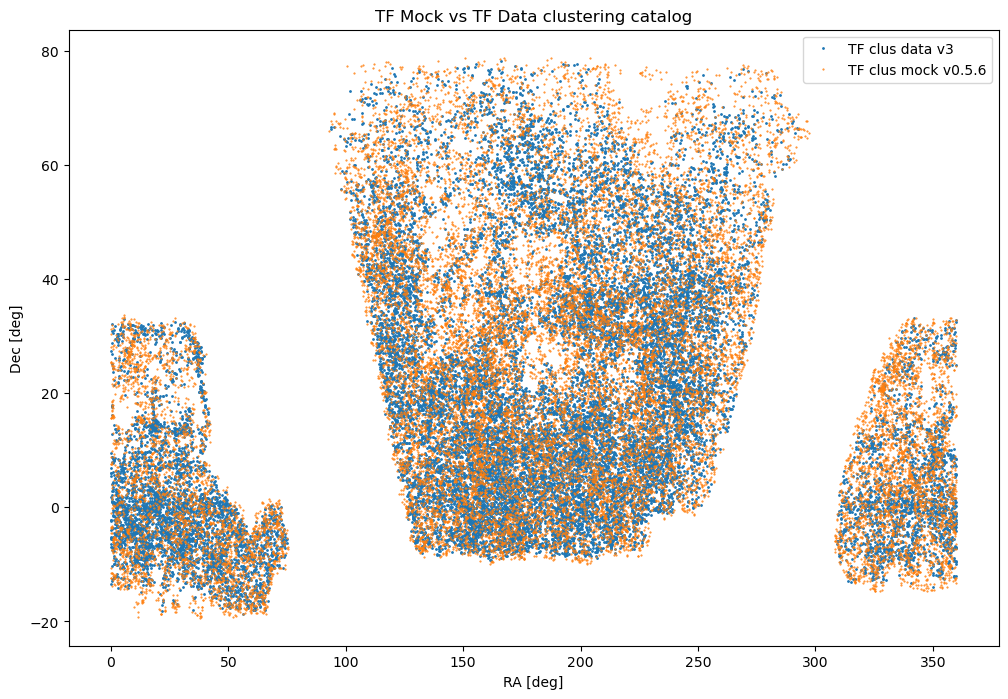

In [5]:
plt.figure(figsize=(12, 8))
plt.plot(d_data['RA'], d_data['DEC'], '.', ms=2, alpha=1, label=data_label)
plt.plot(m_data['RA'], m_data['DEC'], '.', ms=1, alpha=1, label=mock_label )
plt.title('TF Mock vs TF Data clustering catalog')
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')
plt.legend()

Text(0, 0.5, 'Dec [deg]')

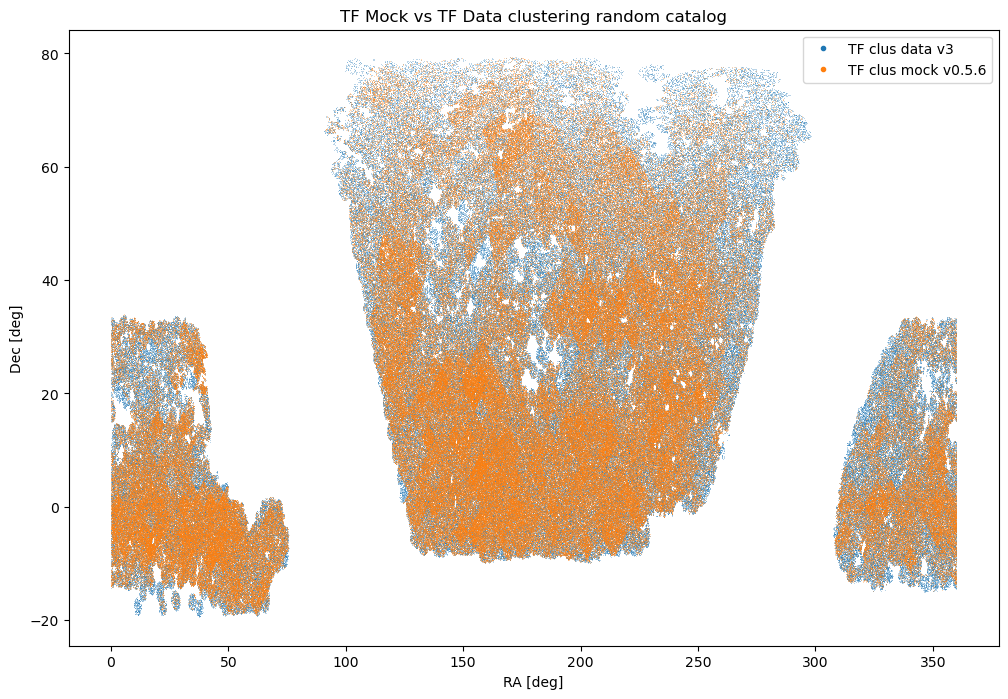

In [24]:
plt.figure(figsize=(12, 8))
plt.plot(m_rand['RA'][::], m_rand['DEC'][::], ',', ms=0.5, alpha=0.3)
plt.plot(d_rand['RA'][::], d_rand['DEC'][::], ',', ms=0.5, alpha=0.3)
plt.plot([], [], 'C0.', label=data_label)
plt.plot([], [], 'C1.', label=mock_label)
plt.title('TF Mock vs TF Data clustering random catalog')
plt.legend()
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]') 

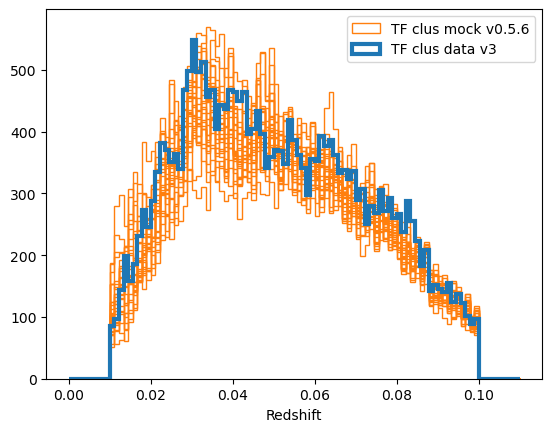

In [6]:
zbins = np.linspace(0, 0.11, 100)
for phase in range(1):
    for real in range(27):
        m_data_temp = fits.open(cfg.mock_tf_clus_data.format(phase=phase, real=real))[1].data
        label = mock_label if phase == 0 and real ==0 else None 
        _=plt.hist(m_data_temp['Z'], color='C1', bins=zbins, histtype='step', alpha=1, label=label)

_=plt.hist(d_data['Z'], bins=zbins, histtype='step', lw=3,
           label=data_label)

plt.xlabel('Redshift')
plt.legend()

In [7]:
area_ngc = 8500.3589 # sq deg
area_sgc = 3610.6785 # sq deg

area_tot = area_ngc + area_sgc # sq deg

zbins = np.linspace(0, 0.11, 100)
zcen = 0.5*(zbins[:-1]+zbins[1:]) 
zvol = (cosmo.comoving_volume(zbins[1:]).value-cosmo.comoving_volume(zbins[:-1]).value)*(1/(4.*np.pi*((180./np.pi)**2)))

def get_nz(z, weights=None,  area=area_tot):
    nz, _ = np.histogram(z, bins=zbins, weights=weights)
    return nz/zvol/area

In [8]:
m_nzs = []
for phase in range(1):
    for real in range(27):
        m_data_temp = fits.open(cfg.mock_tf_clus_data.format(phase=phase, real=real))[1].data
        m_nz = get_nz(m_data_temp['Z'], area=area_tot)
        m_nzs.append(m_nz)
m_nzs = np.array(m_nzs) 
print(m_nzs.shape)

(27, 99)


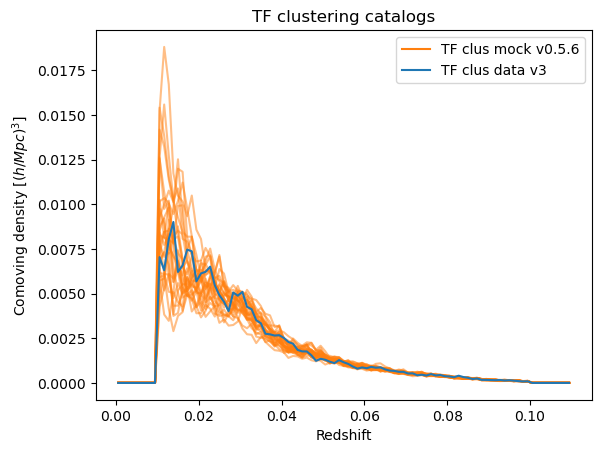

In [10]:
for m_nz in m_nzs:      
    plt.plot(zcen, m_nz, 'C1-', alpha=0.5)
plt.plot([], [], 'C1-', label=mock_label)

d_nz = get_nz(d_data['Z'], weights=d_data['WEIGHT'], area=area_tot)
plt.plot(zcen, d_nz, 'C0-', label=data_label)

plt.ylabel('Comoving density [${(h/Mpc)}^3$]')
plt.xlabel('Redshift')
plt.title('TF clustering catalogs')
plt.legend()
plt.savefig(f'../plots/nz_TF_clus_mock_{cfg.version_tf_clus}_data_{cfg.data_tf_full_version}.pdf')